# Exploration and cleaning of data from dbCAN-PUL

In [5]:
import polars
import matplotlib.pyplot as plt
import numpy as np
import gb_io
from Bio import Entrez
from Bio import Blast

EMAIL = 'b.rosenthal@lumc.com'
Blast.email = EMAIL
Entrez.email = EMAIL


## Cleaning gene/feature tables
Only removing the accession ID of the master record for WGS contigs, which is everything after the first space.


From https://pmc.ncbi.nlm.nih.gov/articles/PMC3531190/: Within GenBank, WGS master records (see below) contain no sequence data, but rather show the descriptive information and range of accession numbers of the contigs submitted as part of that WGS project. NCBI is transitioning to a point where we will no longer assign GI (GenInfo) numbers to these individual contigs, particularly for data from low coverage, fragmented or unannotated assemblies of eukaryotic genomes. Contigs without GI numbers will not be available from the Nucleotide database; instead, users may view these records in the WGS browser linked from the WGS feature of any WGS master record. The WGS browser provides the complete descriptive information from the master record of the project, interactive views of the FASTA of every contig record and also provides links to the FTP files for all the contigs of the entire project.`

In [ ]:
# load genes file
genes_path = '../data/preprocessed/cazy_results/genome.genes.parquet'
features_path = '../data/preprocessed/cazy_results/genome.features.parquet'
cluster_path = '../data/dbCAN-PUL_Feb-2025.xlsx'

def clean_genes_table(genes_path: str, col_name: str="sequence_id") -> polars.DataFrame:
    genes_df = polars.read_parquet(genes_path)
    # Clean up sequence ID by only taking first identifier before any spaces
    genes_df = genes_df.with_columns([
        polars.col(col_name).map_elements(lambda x: x.split(' ')[0].strip()).alias(col_name)
    ]).sort(col_name)
    return genes_df


def clean_cluster_table(cluster_path: str) -> polars.DataFrame:
    # read dbCAN PUL annotations from excel sheet
    pul_annotations = polars.read_excel(cluster_path).select(['ID', 'genomic_accession_number', 'nucleotide_position_range', 'ncbi_species_tax_id'])
    # add a column for the start and end positions of the PULs
    pul_annotations = pul_annotations.with_columns([
        polars.col('nucleotide_position_range').map_elements(lambda x: int(x.split(',')[0].split('-')[0]), int).alias('start'),
        polars.col('nucleotide_position_range').map_elements(lambda x: int(x.split(',')[0].split('-')[1]), int).alias('end'),
        polars.col('genomic_accession_number').map_elements(lambda x: x.split('.')[0].strip()).alias('sequence_id'),
        polars.col('ID').map_elements(lambda x: x.strip()).alias('cluster_id'),
        polars.col('ncbi_species_tax_id').alias('tax_id'),
    ]).sort('sequence_id')
    return pul_annotations.select(['sequence_id', 'cluster_id', 'start', 'end', 'tax_id'])


def save_tables(genes_table: polars.DataFrame, features_table: polars.DataFrame, cluster_table: polars.DataFrame):
    # save cleaned tables to parquet files for later use
    genes_table.write_csv('../data/preprocessed/cazy_results/genome.genes.cleaned.tsv', separator='\t')
    features_table.write_csv('../data/preprocessed/cazy_results/genome.features.cleaned.tsv', separator='\t')
    cluster_table.write_csv('../data/preprocessed/genome.cluster.cleaned.tsv', separator='\t')


genes_table = clean_genes_table(genes_path)
features_table = clean_genes_table(features_path)
cluster_table = clean_cluster_table(cluster_path)

display(genes_table)
display(features_table)
display(cluster_table)

sequence_id,protein_id,start,end,strand
str,str,u32,u32,str
"""AAXF02000034""","""AAXF02000034 AAXF02000000_1""",2,470,"""+"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_2""",1111,1528,"""-"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_3""",1758,1971,"""+"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_4""",1994,2945,"""-"""
"""AAXF02000034""","""AAXF02000034 AAXF02000000_5""",2991,3723,"""-"""
…,…,…,…,…
"""Z49992""","""Z49992_2""",2251,2560,"""+"""
"""Z49992""","""Z49992_3""",2575,3934,"""+"""
"""Z49992""","""Z49992_4""",4021,4285,"""+"""


sequence_id,protein_id,start,end,strand,domain,hmm,i_evalue,pvalue,domain_start,domain_end
str,str,u32,u32,str,str,str,f64,f64,u32,u32
"""AAXF02000034""","""AAXF02000034 AAXF02000000_49""",58562,60638,"""-""","""CBM32""","""CAZy""",1.3850e-10,1.5828e-13,555,676
"""AAXF02000034""","""AAXF02000034 AAXF02000000_49""",58562,60638,"""-""","""GH20""","""CAZy""",4.1920e-121,4.7908e-124,150,498
"""AAXF02000034""","""AAXF02000034 AAXF02000000_50""",60637,62962,"""-""","""CBM32""","""CAZy""",1.6764e-14,1.9159e-17,637,747
"""AAXF02000034""","""AAXF02000034 AAXF02000000_50""",60637,62962,"""-""","""GH20""","""CAZy""",1.0158e-122,1.1610e-125,153,509
"""AAXF02000034""","""AAXF02000034 AAXF02000000_51""",62996,65588,"""-""","""GH2""","""CAZy""",2.7652e-112,3.1603e-115,21,779
…,…,…,…,…,…,…,…,…,…,…
"""Z49241""","""Z49241_3""",1345,2305,"""+""","""GH43_37""","""CAZy""",1.5188e-8,1.7358e-11,89,262
"""Z49241""","""Z49241_3""",1345,2305,"""+""","""GH43_3""","""CAZy""",4.4348e-20,5.0684e-23,64,307
"""Z49241""","""Z49241_3""",1345,2305,"""+""","""GH43_8""","""CAZy""",4.2594e-10,4.8678e-13,75,151


sequence_id,cluster_id,start,end,tax_id
str,str,i64,i64,str
"""AAXF02000034""","""PUL0415""",53978,62950,"""28116"""
"""AAXF02000045""","""PUL0416""",159078,179453,"""28116"""
"""AAXF02000045""","""PUL0417""",182417,201731,"""28116"""
"""AAXF02000047""","""PUL0167""",109596,128600,"""28116"""
"""AAXF02000047""","""PUL0178""",106585,128684,"""28116"""
…,…,…,…,…
"""X78853""","""PUL0265""",438,3103,"""1288"""
"""X81461""","""PUL0351""",3171,8055,"""562"""
"""Z25795""","""PUL0058""",463,8375,"""1423"""


In [4]:
# compare sequence IDs
ids_from_genes = set(genes_table['sequence_id'])
ids_from_cluster = set(cluster_table['sequence_id'])

print(f"IDs in Excel but not in genes: {ids_from_cluster - ids_from_genes}")
print(f"IDs in genes but not in Excel: {ids_from_genes - ids_from_cluster}\n")

# investigate duplicate IDs and where they come from
genes_table_raw = polars.read_parquet(genes_path)
cluster_table_raw = polars.read_excel(cluster_path).select(['ID', 'genomic_accession_number', 'nucleotide_position_range'])

print("In genes (raw): ", genes_table_raw['sequence_id'].unique().count())
print("In cluster (raw): ", cluster_table_raw['genomic_accession_number'].unique().count())

stripped_ids = cluster_table_raw['genomic_accession_number'].map_elements(lambda x: x.strip()).unique().to_list()
print("In cluster (stripped): ", len(stripped_ids))
processed_cluster_ids = cluster_table['sequence_id'].unique()
print("In cluster (stripped and no version num): ", len(processed_cluster_ids), '\n')

processed_ids = {}
for id in stripped_ids:
    processed_id = id.split('.')[0].strip()
    if processed_id in processed_ids.keys():
        print(f"Duplicate found. Current ID: {id}, previously seen ID: {processed_ids[processed_id]}")
        continue
    else:
        processed_ids[processed_id] = id


IDs in Excel but not in genes: {'Ga0139390_150'}
IDs in genes but not in Excel: {'ADWO01000020'}

In genes (raw):  370
In cluster (raw):  375
In cluster (stripped):  373
In cluster (stripped and no version num):  370 

Duplicate found. Current ID: CP001656.1, previously seen ID: CP001656
Duplicate found. Current ID: NC_000964, previously seen ID: NC_000964.3
Duplicate found. Current ID: DQ868502, previously seen ID: DQ868502.2


Conclusion 1: Two accession IDs do not match between the entries: `Ga0139390_150` and `ADWO01000020`. 

`Ga0139390_150` is not a genbank/ncbi accession ID, but from a DOE-JGI GOLD entry https://gold.jgi.doe.gov/analysis_project?id=Ga0139390. Downloading the genome requires an orchid ID. Based on NCBI taxon ID, 749906 this could also be investigated further at https://www.ncbi.nlm.nih.gov/bioproject/301235.

The second is from a PUL entry in dbCAN-PUL that spans over 2 contigs from the same WGS master record (saved as `ADWO01000021.1, ADWO01000020.1`). Initial handling of the dbCAN-PUL excel sheet led to discarding `ADWO01000020` by splitting on `.` to remove the version number...
Since the PUL spans over 2 contigs, it might be better to either merge them into 1 sequence and include that in the data, or remove it. Keeping them as 2 separate PULs is probably not very accurate.

Conclusion 2: Cleaning IDs (removing spaces and version numbers) leads to 5 less unique values. 2 due to spaces at the end, 3 due to the excel sheet containing both versioned and unversioned ids.

In total, the data should contain **368 genomes**, assuming we remove the mismatching entries.

In [ ]:
#PUL0456	20622018	microarray,RNA-Seq	ADWO01000021.1,ADWO01000020.1	1-5954,1-18196	xylan	PBR_RS03345-PBR_RS03360+PBR_RS02950-PBR_RS02990		Prevotella bryantii	77095	degradation	default	default	default	default	1	yes	4	12	GH43_10,GH43_1,GH67,GH10	

# replace sequence id by "CP091800.1" and change start and end, for ADWO01000021
cluster_table = cluster_table[cluster_table['cluster_id'] == 'PUL0456_1'].with_columns([
    polars.lit("CP091800.1").alias('sequence_id'),
    polars.lit(811569).alias('start'),
    polars.lit(817528).alias('end')
])
# second entry for ADWO01000020
cluster_table = cluster_table[cluster_table['cluster_id'] == 'PUL0456_2'].with_columns([
    polars.lit("CP091800.1").alias('sequence_id'),
    polars.lit(49194).alias('start'),
    polars.lit(67389).alias('end')
])

In [ ]:
# get the other genome into a single genbank file
jgi_genome = "../data/IMG_2703719109/IMG Data/99440.assembled.gbk"
contig_id = "Ga0139390_150 Ga0139390_150"

for record in gb_io.iter(jgi_genome):
    if record.definition == contig_id:
        gb_io.dump(record, "../data/Ga0139390_150.gb")

In [ ]:
# add new genome to the genbank file with the other dbCAN genomes
# !cat ../data/Ga0139390_150.gb >> ../data/dbCAN-PUL-genomes_unique.gb 

In [ ]:
# save cleaned tables for later use
save_tables(genes_table, features_table, cluster_table)

Genes table size: (612905, 5)
Features table size: (212855, 11)
Cluster table size: (631, 4)


## Combining gene and cluster tables
For visualization purposes, and possibly useful for later

In [6]:
def join_gene_and_PUL_table(
    gene_table: polars.DataFrame,
    cluster_table: polars.DataFrame,
    buffer: int = 1000,
) -> polars.DataFrame:

    """
    Join a gene table with a PUL annotation table.
    """

    labled_gene_table = (
        cluster_table
        .rename({"start": "pul_start", "end": "pul_end"}) # avoid column name conflicts
        .join(
            gene_table,
            on="sequence_id",
            how="inner",
            validate="m:m",
        )
        .with_columns(
            polars.when(
                polars.col("start") >= polars.col("pul_start") - buffer, # allow for some buffer around the PUL boundaries
                polars.col("end") <= polars.col("pul_end") + buffer,
            )
            .then(True)
            .otherwise(False)
            .cast(polars.Boolean)
            .alias("is_PUL")
        )
        # aggregate by protein_id to determine if protein is in any PUL
        .group_by("protein_id")
        .agg(
            polars.col("is_PUL").any().alias("is_PUL"),
            polars.col("sequence_id").first().alias("sequence_id"),
            polars.col("start").first().alias("start"),
            polars.col("end").first().alias("end"),
            polars.col("strand").first().alias("strand"),
        )
        .sort(by=["sequence_id", "start", "end"])
        .with_row_index(name="gene_id", offset=0)  # important
        .select(["sequence_id", "protein_id", "start", "end", "strand", "is_PUL"])
    )

    return labled_gene_table

genes_with_puls = join_gene_and_PUL_table(genes_table, cluster_table)
print(f"Total of {genes_with_puls['is_PUL'].sum()} genes are in PULs, out of {genes_with_puls.shape[0]} total genes.")

Total of 8082 genes are in PULs, out of 612905 total genes.


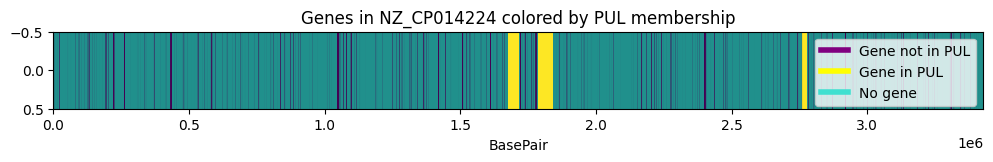

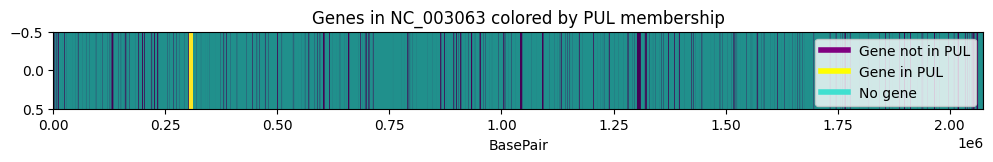

In [ ]:
def plot_PULs_in_genome(labeled_table: polars.DataFrame, cluster_table: polars.DataFrame, sequence_id: str):
    # Filter the table for the given sequence_id
    subset = labeled_table.filter(polars.col("sequence_id") == sequence_id)
    subset_puls = cluster_table.filter(polars.col("sequence_id") == sequence_id)
    # get range of genes in PULs for this sequence_id
    contig_range = np.zeros(subset['end'].max(), dtype=int)
    # set locations where genes are to 1
    gene_ranges = [[row[2]+1, row[3]+1] for row in subset.iter_rows()] # NOTE: unsure about off by one errors here, need to check with actual data
    pul_ranges = [[row[2], row[3]] for row in subset_puls.iter_rows()]

    for range in gene_ranges:
        contig_range[range[0]:range[1]] = 1
    
    for range in pul_ranges:
        contig_range[range[0]:range[1]] = 2


    plt.figure(figsize=(12, 1))
    plt.imshow([contig_range], aspect='auto', cmap='viridis', vmin=0, vmax=2)
    plt.title(f"Genes in {sequence_id} colored by PUL membership")
    plt.xlabel("BasePair")
    # add legend
    plt.legend(
        handles=[
            plt.Line2D([0], [0], color='purple', lw=4, label='Gene not in PUL'),
            plt.Line2D([0], [0], color='yellow', lw=4, label='Gene in PUL'),
            plt.Line2D([0], [0], color='turquoise', lw=4, label='No gene'),
        ],
        loc='upper right'
    )
    plt.show()

for sequence_id in genes_with_puls['sequence_id'].unique()[:2]:
    plot_PULs_in_genome(genes_with_puls, cluster_table, sequence_id)

In [ ]:
# create file of unique accession ids from cluster tables
# unique_accessions = cluster_table['sequence_id'].unique().to_frame(name='sequence_id')
# unique_accessions.write_csv('../data/dbCAN-PUL_sequence_ids.tsv', separator='\t')

In [ ]:
# with open('../data/temp_accessed.txt', 'r') as f:
#     ids = f.read().splitlines()

# unique_accessions = polars.read_csv('../data/dbCAN-PUL_sequence_ids.tsv', separator='\t')
# done_ids = [id.split(' ')[3] for id in ids]
# print(len(set(unique_accessions['sequence_id'])))
# print(len(set(done_ids)))
# unprocessed_ids = set(unique_accessions['sequence_id']) - (set(done_ids))

# # save unprocessed ids to file for later use
# with open('../data/temp_unprocessed_ids.tsv', 'w') as f:
#     f.write('sequence_id\n')
#     for id in unprocessed_ids:
#         f.write(f'{id}\n')

# Cleaning (scraped) data from PULDB

In [ ]:
puldb_data = polars.read_parquet('../data/puldb_data.parquet')
puldb_data = puldb_data.with_columns([
    polars.col('accession').map_elements(lambda x: x.split('.')[0].strip()).alias('sequence_id'),
    polars.col('pul_id').alias('cluster_id'),
    polars.col('start_bp').alias('start'),
    polars.col('end_bp').alias('end')  
]).sort('sequence_id')["cluster_id", "sequence_id", "start", "end", "status"]

puldb_data_literature = puldb_data.filter(polars.col("status").eq("literature"))
puldb_data_other = puldb_data.filter(polars.col("status").eq("other"))

display(puldb_data_literature.head())
display(puldb_data_other.head())

cluster_id,sequence_id,start,end,status
i64,str,i64,i64,str
24469,"""CP016359""",228516,249102,"""literature"""
24470,"""CP016359""",326512,365322,"""literature"""
24471,"""CP016359""",363304,381160,"""literature"""
24472,"""CP016359""",397120,435831,"""literature"""
24473,"""CP016359""",1091860,1110518,"""literature"""


cluster_id,sequence_id,start,end,status
i64,str,i64,i64,str
9581,"""A37SDRAFT_scaffold_12""",28565,42432,"""other"""
9582,"""A37SDRAFT_scaffold_3""",174673,184775,"""other"""
9583,"""A37SDRAFT_scaffold_75""",0,10701,"""other"""
7989,"""A3CYDRAFT_scaffold_0""",225291,238543,"""other"""
9509,"""A3EMDRAFT_scaffold_15""",101090,111658,"""other"""


In [10]:
# compare with cluster table
ids_from_puldb = set(puldb_data_literature['sequence_id'])
ids_overlap = ids_from_puldb.intersection(ids_from_cluster)
print(f'ids_overlap: {ids_overlap},\ntotal of {len(ids_overlap)}')
print(f"total unique ids in puldb: {len(ids_from_puldb)}")

ids_overlap: {'CU207366', 'NC_009441', 'NC_013132', 'NC_016610', 'CP016359', 'NC_004663', 'CP019300', 'NZ_ABJL02000008', 'FQ312004', 'FP929033', 'FP476056'},
total of 11
total unique ids in puldb: 47


In [12]:
# find out which IDs are invalid
from Bio import Entrez
import json
import tqdm

invalid_ids = []
Entrez.email = 'b.rosenthal@lumc.com'
for acc in tqdm.tqdm(list(ids_from_puldb)):
    handle = Entrez.esummary(
        db="nuccore",
        id=acc,
        retmode="json"
    )
    record = handle.read()
    record = json.loads(record)
    if "error" in record.keys():
        invalid_ids.append(acc)

    handle.close()

print(invalid_ids)

100%|██████████| 47/47 [00:19<00:00,  2.40it/s]

['SEQ15336-2_ori', 'Contig5_1_7083079', 'P164DRAFT_scf7180000000008_quiver', 'SEQ15336-1', 'FG27DRAFT_unitig_0_quiver_dupTrim_7536', 'P164DRAFT_scf7180000000009_quiver']


In [19]:
# get PULids of invalid accession IDs
invalid_pul_ids = puldb_data_literature.filter(
    polars.col("sequence_id").is_in(invalid_ids))["cluster_id", "sequence_id"].group_by("sequence_id").agg(polars.col("cluster_id").first().alias("cluster_id"))
print(invalid_pul_ids)

shape: (6, 2)
┌─────────────────────────────────┬────────────┐
│ sequence_id                     ┆ cluster_id │
│ ---                             ┆ ---        │
│ str                             ┆ i64        │
╞═════════════════════════════════╪════════════╡
│ Contig5_1_7083079               ┆ 28073      │
│ FG27DRAFT_unitig_0_quiver_dupT… ┆ 19097      │
│ P164DRAFT_scf7180000000008_qui… ┆ 19759      │
│ P164DRAFT_scf7180000000009_qui… ┆ 19761      │
│ SEQ15336-1                      ┆ 28289      │
│ SEQ15336-2_ori                  ┆ 28475      │
└─────────────────────────────────┴────────────┘


### Summary:
There is a total of 675 PULs from 47 unique accession IDs in the literature based part of PULDB

Out of these, 6 IDs are not valid NCBI identifiers. 3 of them are from one paper https://doi.org/10.1111/1462-2920.14414Digital
- 'FG27DRAFT_unitig_0_quiver_dupTrim_7536', from Salegentibacter sp. Hel_I_6. Data on DOE-JGI GOLD, analysis project ID Ga0040974, genbank ID NZ_JQNQ01000001.1
- 'P164DRAFT_scf7180000000008_quiver', from Flavimarina sp. Hel_I_48. Data on DOE-JGI GOLD, analysis project ID Ga0005363, genbank ID JPOL01000002.1 (scaffold ...8)
- 'P164DRAFT_scf7180000000009_quiver', from Flavimarina sp. Hel_I_48. Data on DOE-JGI GOLD, analysis project ID Ga0005363, genbank ID JPOL01000003.1 (scaffold ...9)

- 'SEQ15336-1', from Bacteroides thetaiotaomicron 7330 in paper https://www.science.org/doi/10.1126/science.aac5992. No data provided...
- 'Contig5_1_7083079', from Bacteroides cellulosilyticus WH2 in paper https://doi.org/10.1371/journal.pbio.1001637. No data provided...
- 'SEQ15336-2_ori', from Bacteroides ovatus ATCCC 8483 in paper https://doi.org/10.1371/journal.pbio.1001221. No data provided...


In [ ]:
# replace invalid ids with genbank where available
id_mapping = {
    "FG27DRAFT_unitig_0_quiver_dupTrim_7536": "NZ_JQNQ01000001",
    "P164DRAFT_scf7180000000008_quiver": "JPOL01000002",
    "P164DRAFT_scf7180000000009_quiver": "JPOL01000003"
}
puldb_data_literature = puldb_data_literature.with_columns(polars.col("sequence_id").replace(id_mapping))

# remove other invalid ids that cannot be mapped to genbank accessions
invalid_ids = ['SEQ15336-2_ori', 'Contig5_1_7083079', 'SEQ15336-1']
puldb_data_literature = puldb_data_literature.filter(~polars.col("sequence_id").is_in(invalid_ids))
print(puldb_data_literature.shape)

(358, 5)


In [ ]:
# # save puldb_data_literature
# puldb_data_literature.write_csv('../data/puldb_literature_PULs.tsv', separator='\t')

# # save unique sequence ids for genome search
# unique_sequences = puldb_data_literature['sequence_id'].unique().to_frame(name='sequence_id')
# unique_sequences.write_csv('../data/puldb_literature_sequence_ids.tsv', separator='\t')